In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Загружаем тестовые данные
X_train = pd.read_csv('X_train.csv') # Нужен только для названий колонок
X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv').squeeze()

# Загружаем нашу лучшую сохраненную модель
best_model = CatBoostClassifier()
best_model.load_model('catboost_best_model.cbm')

print("Данные и модель успешно загружены!")

Данные и модель успешно загружены!


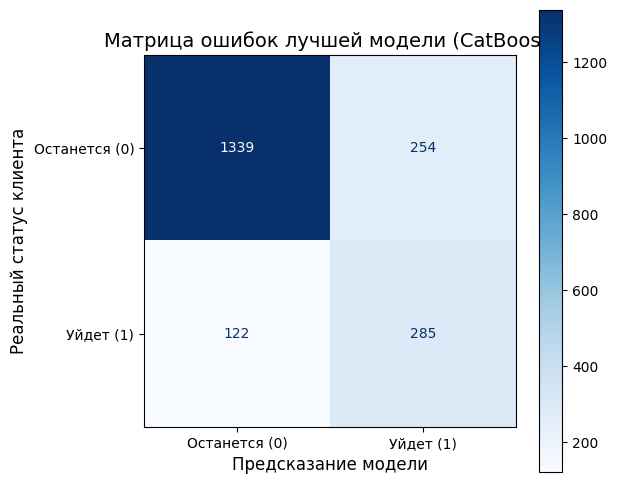


--- РАСШИФРОВКА МАТРИЦЫ ---
True Negatives (Левый верхний): 1339 — Модель сказала 'Останется', и он реально остался (Верно).
True Positives (Правый нижний): 285 — Модель сказала 'Уйдет', и он реально ушел (Верно!).
False Positives (Правый верхний): 254 — Модель сказала 'Уйдет', но он остался (Ложная тревога).
False Negatives (Левый нижний): 122 — Модель сказала 'Останется', но он ушел (ОПАСНАЯ ОШИБКА).


In [ ]:
# Получаем предсказания на тестовой выборке
y_pred = best_model.predict(X_test)

# Строим матрицу ошибок
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Останется (0)', 'Уйдет (1)'])

# Отрисовка
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, values_format='d', ax=ax)

plt.title('Матрица ошибок лучшей модели (CatBoost)', fontsize=14)
plt.xlabel('Предсказание модели', fontsize=12)
plt.ylabel('Реальный статус клиента', fontsize=12)
plt.show()

print("\n--- РАСШИФРОВКА МАТРИЦЫ ---")
print(f"True Negatives (Левый верхний): {cm[0][0]} — Модель сказала 'Останется', и он реально остался (Верно).")
print(f"True Positives (Правый нижний): {cm[1][1]} — Модель сказала 'Уйдет', и он реально ушел (Верно!).")
print(f"False Positives (Правый верхний): {cm[0][1]} — Модель сказала 'Уйдет', но он остался (Ложная тревога).")
print(f"False Negatives (Левый нижний): {cm[1][0]} — Модель сказала 'Останется', но он ушел (ОПАСНАЯ ОШИБКА).")

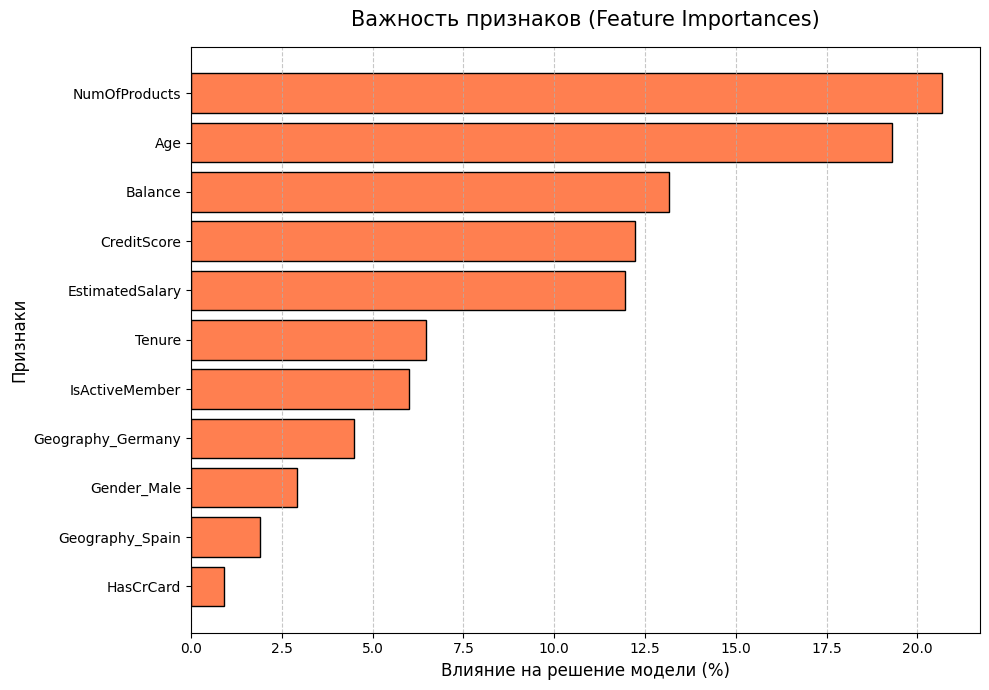

In [ ]:
# Извлекаем веса (важность) каждого признака из модели CatBoost
importances = best_model.get_feature_importance()
feature_names = X_train.columns

# Создаем удобный DataFrame
feature_importances_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Сортируем по возрастанию для красивого графика
feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=True)

# Строим горизонтальную столбчатую диаграмму
plt.figure(figsize=(10, 7))
plt.barh(feature_importances_df['Feature'], feature_importances_df['Importance'], color='coral', edgecolor='black')

plt.title('Важность признаков', fontsize=15, pad=15)
plt.xlabel('Влияние на решение модели (%)', fontsize=12)
plt.ylabel('Признаки', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()